# Advanced Models: Optuna + Tweedie + XGBoost

**Baseline RMSLE**: 0.3749 (LightGBM, default params, log1p MSE).

## Leakage Self-Check

| Пункт | Статус |
|-------|--------|
| **Данные** | Train (≤2017-07-31), Val (08-01—15), Test (08-16—31). Загружаем из parquet, сплит сделан в Phase 3. |
| **Optuna** | Objective: fit на train, evaluate на val. Test **не участвует** в selection. |
| **Early stopping** | По val RMSE — допустимо, т.к. test labels отсутствуют (Kaggle setup). |
| **Новые фичи** | В этом ноутбуке новых фичей не создаём — только тюним модели. |
| **Tweedie** | Обучаем на raw `sales` (без log1p). LightGBM внутренне моделирует `log(E[y])`. |
| **XGBoost** | Те же train/val, тот же набор фичей. Никаких leak-paths. |

**[!] Val используется для model selection (Optuna + early stopping). Это стандартная практика, но означает, что итоговый RMSLE на val — слегка оптимистичен. Финальная честная оценка — на Kaggle leaderboard.**

In [2]:
%pip install optuna xgboost

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/ac/24/7c731839566d30dc70556d9824ef17692d896c15e3df627bce8c16f753e1/optuna-4.8.0-py3-none-any.whl.metadata
  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/d2/29/6533c317b74f707ea28f8d633734dbda2119bbadfc61b2f3640ba835d0f7/alembic-1.18.4-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/6d/c1/e419ef3723a074172b68aaa89c9f3de486ed4c2399e2dbd8113a4fdcaf9e/colorlog-6.10.1-py3-none-any.whl.metadata
  Obtaining dependency information for sqlalchemy>=1.4.2 from https://files.pythonhosted.org/packages/f2/af/c3c7e1f3a2b383155a16454df62ae8c62a30dd238e42e68c24cebebbfae6/sqlalchemy-2.0.48-cp


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb
import xgboost as xgb
import optuna
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

processed_dir = os.path.join('..', 'data', 'processed')
artifacts_dir = os.path.join('..', 'artifacts')

train = pd.read_parquet(os.path.join(processed_dir, 'train_fe.parquet'))
val   = pd.read_parquet(os.path.join(processed_dir, 'val_fe.parquet'))
test  = pd.read_parquet(os.path.join(processed_dir, 'test_fe.parquet'))

DROP_COLS = ['date', 'sales']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
CAT_FEATURES = ['store_nbr', 'family', 'city', 'state', 'type', 'cluster',
                 'day_of_week', 'month', 'quarter']

X_train, y_train = train[FEATURE_COLS], train['sales']
X_val,   y_val   = val[FEATURE_COLS],   val['sales']
X_test           = test[FEATURE_COLS]

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)


def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Logarithmic Error."""
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Features: {len(FEATURE_COLS)} | Categorical: {len(CAT_FEATURES)}')
print(f'Baseline RMSLE (Phase 4): 0.3749')

Train: (2981286, 30) | Val: (26730, 30) | Test: (28512, 30)
Features: 30 | Categorical: 9
Baseline RMSLE (Phase 4): 0.3749


## 1. Optuna: LightGBM Hyperparameter Search

**Search space:**
- `num_leaves`: [63, 512] — контролирует сложность деревьев
- `learning_rate`: [0.01, 0.15] — скорость обучения
- `feature_fraction`: [0.5, 1.0] — доля фичей в каждом дереве
- `bagging_fraction`: [0.5, 1.0] — доля сэмплов
- `min_child_samples`: [10, 200] — минимум объектов в листе
- `lambda_l1`, `lambda_l2`: [1e-3, 10] — регуляризация

**Стратегия**: 50 trials с early stopping (30 rounds), max 1000 деревьев на trial для скорости.

In [4]:
dtrain_lgb = lgb.Dataset(X_train, label=y_train_log, categorical_feature=CAT_FEATURES, free_raw_data=False)
dval_lgb   = lgb.Dataset(X_val,   label=y_val_log,   reference=dtrain_lgb, free_raw_data=False)


def lgb_objective(trial: optuna.Trial) -> float:
    params = {
        'objective':         'regression',
        'metric':            'rmse',
        'verbosity':         -1,
        'seed':              SEED,
        'n_jobs':            -1,
        'num_leaves':        trial.suggest_int('num_leaves', 63, 512),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
    }

    model = lgb.train(
        params, dtrain_lgb,
        num_boost_round=1000,
        valid_sets=[dval_lgb],
        valid_names=['val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    # RMSE в log-пространстве = RMSLE
    return model.best_score['val']['rmse']


study_lgb = optuna.create_study(direction='minimize', study_name='lgbm_regression')

t0 = time.time()
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
elapsed = time.time() - t0

print(f'\n=== Optuna LightGBM Results ===')
print(f'Trials: {len(study_lgb.trials)} | Time: {elapsed:.0f}s')
print(f'Best val RMSE (=RMSLE): {study_lgb.best_value:.4f}')
print(f'Improvement over baseline: {0.3749 - study_lgb.best_value:+.4f}')
print(f'\nBest params:')
for k, v in study_lgb.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


=== Optuna LightGBM Results ===
Trials: 50 | Time: 4275s
Best val RMSE (=RMSLE): 0.3730
Improvement over baseline: +0.0019

Best params:
  num_leaves: 504
  learning_rate: 0.03553140444512885
  feature_fraction: 0.619568701120978
  bagging_fraction: 0.8857593994524801
  bagging_freq: 5
  min_child_samples: 144
  lambda_l1: 0.03349730805739699
  lambda_l2: 2.2814180351609914


Top-10 trials:
 number    value               duration
     49 0.372978 0 days 00:01:33.569116
     48 0.373083 0 days 00:02:34.526451
     33 0.373125 0 days 00:02:28.121782
     41 0.373316 0 days 00:02:15.397933
     42 0.373704 0 days 00:01:50.009919
     23 0.373769 0 days 00:01:57.842076
     34 0.373817 0 days 00:02:15.788857
     45 0.373925 0 days 00:01:54.389928
     35 0.373993 0 days 00:02:23.115828
     28 0.374126 0 days 00:02:33.957844


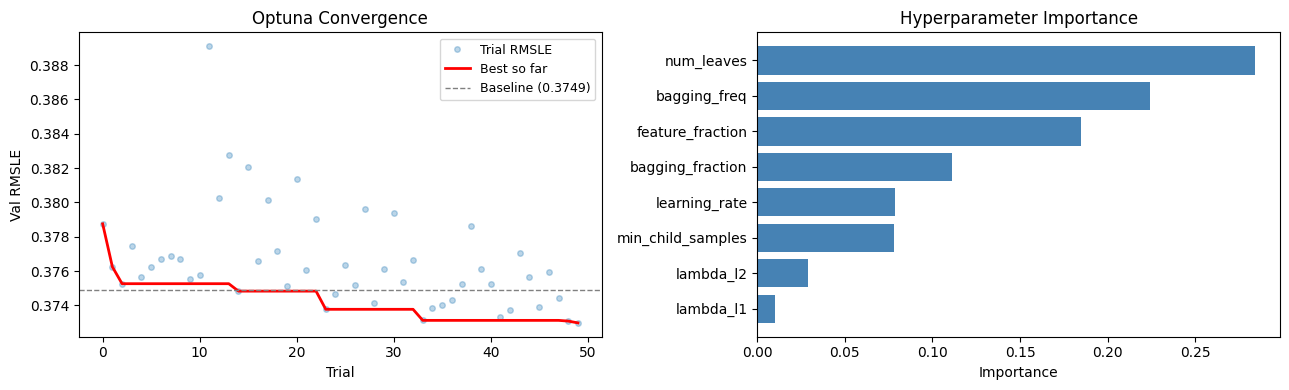

In [5]:
# Топ-10 trials
trials_df = study_lgb.trials_dataframe().sort_values('value')
print('Top-10 trials:')
print(trials_df[['number', 'value', 'duration']].head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Convergence
values = [t.value for t in study_lgb.trials]
best_so_far = np.minimum.accumulate(values)
axes[0].plot(values, 'o', alpha=0.3, markersize=4, label='Trial RMSLE')
axes[0].plot(best_so_far, 'r-', linewidth=2, label='Best so far')
axes[0].axhline(0.3749, color='gray', linestyle='--', linewidth=1, label='Baseline (0.3749)')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val RMSLE')
axes[0].set_title('Optuna Convergence')
axes[0].legend(fontsize=9)

# Param importance
importances = optuna.importance.get_param_importances(study_lgb)
ax = axes[1]
ax.barh(list(importances.keys())[::-1], list(importances.values())[::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Hyperparameter Importance')

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'optuna_lgbm.png'), dpi=120)
plt.show()

## 2. Retrain Best LightGBM (log1p MSE)

Берём лучшие параметры из Optuna, но обучаем с `num_boost_round=2000` и `early_stopping=50` для полной конвергенции.

In [6]:
best_params_lgb = {
    'objective':   'regression',
    'metric':      'rmse',
    'verbosity':   -1,
    'seed':        SEED,
    'n_jobs':      -1,
    **study_lgb.best_params,
}

model_lgb_tuned = lgb.train(
    best_params_lgb, dtrain_lgb,
    num_boost_round=2000,
    valid_sets=[dtrain_lgb, dval_lgb],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=200),
    ],
)

pred_lgb_tuned_log = model_lgb_tuned.predict(X_val, num_iteration=model_lgb_tuned.best_iteration)
pred_lgb_tuned     = np.expm1(pred_lgb_tuned_log).clip(0)
score_lgb_tuned    = rmsle(y_val.values, pred_lgb_tuned)

print(f'\nLGBM Tuned — iterations: {model_lgb_tuned.best_iteration}, val RMSLE: {score_lgb_tuned:.4f}')

Training until validation scores don't improve for 50 rounds
[200]	train's rmse: 0.360609	val's rmse: 0.378329
[400]	train's rmse: 0.342831	val's rmse: 0.374256
[600]	train's rmse: 0.333696	val's rmse: 0.37309
Early stopping, best iteration is:
[574]	train's rmse: 0.334736	val's rmse: 0.372978

LGBM Tuned — iterations: 574, val RMSLE: 0.3730


## 3. LightGBM Tweedie

Tweedie distribution моделирует zero-inflated continuous data (31.6% нулей).
- Обучаем на **raw `sales`** (не log1p) — LightGBM внутренне использует `log(E[y])`.
- `tweedie_variance_power ∈ [1.0, 1.99]`: 1.0 → Poisson, 2.0 → Gamma. Для наших данных ~1.5 оптимально.
- RMSLE считаем на выходных предсказаниях в оригинальном масштабе.

In [7]:
# Tweedie Dataset — на RAW sales (не log1p!)
dtrain_tw = lgb.Dataset(X_train, label=y_train, categorical_feature=CAT_FEATURES, free_raw_data=False)
dval_tw   = lgb.Dataset(X_val,   label=y_val,   reference=dtrain_tw, free_raw_data=False)


def tweedie_objective(trial: optuna.Trial) -> float:
    params = {
        'objective':              'tweedie',
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.01, 1.99),
        'metric':                 'rmse',
        'verbosity':              -1,
        'seed':                   SEED,
        'n_jobs':                 -1,
        'num_leaves':        trial.suggest_int('num_leaves', 63, 512),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
    }

    model = lgb.train(
        params, dtrain_tw,
        num_boost_round=1000,
        valid_sets=[dval_tw],
        valid_names=['val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    pred = model.predict(X_val, num_iteration=model.best_iteration).clip(0)
    return rmsle(y_val.values, pred)


study_tw = optuna.create_study(direction='minimize', study_name='lgbm_tweedie')

t0 = time.time()
study_tw.optimize(tweedie_objective, n_trials=50, show_progress_bar=True)
elapsed = time.time() - t0

print(f'\n=== Optuna LightGBM Tweedie Results ===')
print(f'Trials: {len(study_tw.trials)} | Time: {elapsed:.0f}s')
print(f'Best val RMSLE: {study_tw.best_value:.4f}')
print(f'Best tweedie_variance_power: {study_tw.best_params["tweedie_variance_power"]:.3f}')
print(f'\nBest params:')
for k, v in study_tw.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


=== Optuna LightGBM Tweedie Results ===
Trials: 50 | Time: 2191s
Best val RMSLE: 0.3869
Best tweedie_variance_power: 1.551

Best params:
  tweedie_variance_power: 1.550505718790678
  num_leaves: 375
  learning_rate: 0.03090409548372573
  feature_fraction: 0.9008023822673736
  bagging_fraction: 0.6920469491091554
  bagging_freq: 1
  min_child_samples: 68
  lambda_l1: 0.02778197857481768
  lambda_l2: 0.011463336338516905


In [8]:
# Retrain Tweedie с лучшими параметрами (полная конвергенция)
best_params_tw = {
    'objective':              'tweedie',
    'metric':                 'rmse',
    'verbosity':              -1,
    'seed':                   SEED,
    'n_jobs':                 -1,
    **study_tw.best_params,
}

model_tw_tuned = lgb.train(
    best_params_tw, dtrain_tw,
    num_boost_round=2000,
    valid_sets=[dtrain_tw, dval_tw],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=200),
    ],
)

pred_tw_tuned = model_tw_tuned.predict(X_val, num_iteration=model_tw_tuned.best_iteration).clip(0)
score_tw_tuned = rmsle(y_val.values, pred_tw_tuned)

print(f'\nLGBM Tweedie — iterations: {model_tw_tuned.best_iteration}, val RMSLE: {score_tw_tuned:.4f}')

Training until validation scores don't improve for 50 rounds
[200]	train's rmse: 217.112	val's rmse: 191.669
Early stopping, best iteration is:
[334]	train's rmse: 190.211	val's rmse: 184.486

LGBM Tweedie — iterations: 334, val RMSLE: 0.3869


## 4. XGBoost Baseline

XGBoost для diversity в будущем ensemble. Обучаем на `log1p(sales)` с лучшими параметрами из Optuna LightGBM (адаптированными). XGBoost нативно обрабатывает NaN.

In [9]:
# def xgb_objective(trial: optuna.Trial) -> float:
#     params = {
#         'objective':       'reg:squarederror',
#         'eval_metric':     'rmse',
#         'tree_method':     'hist',
#         'seed':            SEED,
#         'nthread':         -1,
#         'verbosity':       0,
#         'max_depth':       trial.suggest_int('max_depth', 6, 12),
#         'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
#         'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'min_child_weight':trial.suggest_int('min_child_weight', 5, 100),
#         'reg_alpha':       trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda':      trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#     }

#     dtrain_xgb = xgb.DMatrix(X_train, label=y_train_log)
#     dval_xgb   = xgb.DMatrix(X_val,   label=y_val_log)

#     model = xgb.train(
#         params, dtrain_xgb,
#         num_boost_round=1000,
#         evals=[(dval_xgb, 'val')],
#         early_stopping_rounds=30,
#         verbose_eval=False,
#     )
#     # RMSE в log-пространстве = RMSLE
#     return model.best_score


# study_xgb = optuna.create_study(direction='minimize', study_name='xgboost')

# t0 = time.time()
# study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)
# elapsed = time.time() - t0

# print(f'\n=== Optuna XGBoost Results ===')
# print(f'Trials: {len(study_xgb.trials)} | Time: {elapsed:.0f}s')
# print(f'Best val RMSE (=RMSLE): {study_xgb.best_value:.4f}')
# print(f'\nBest params:')
# for k, v in study_xgb.best_params.items():
#     print(f'  {k}: {v}')

In [10]:
# # Retrain XGBoost с лучшими параметрами
# best_params_xgb = {
#     'objective':       'reg:squarederror',
#     'eval_metric':     'rmse',
#     'tree_method':     'hist',
#     'seed':            SEED,
#     'nthread':         -1,
#     'verbosity':       0,
#     **study_xgb.best_params,
# }

# dtrain_xgb_final = xgb.DMatrix(X_train, label=y_train_log)
# dval_xgb_final   = xgb.DMatrix(X_val,   label=y_val_log)
# dtest_xgb_final  = xgb.DMatrix(X_test)

# model_xgb_tuned = xgb.train(
#     best_params_xgb, dtrain_xgb_final,
#     num_boost_round=2000,
#     evals=[(dtrain_xgb_final, 'train'), (dval_xgb_final, 'val')],
#     early_stopping_rounds=50,
#     verbose_eval=200,
# )

# pred_xgb_log = model_xgb_tuned.predict(dval_xgb_final, iteration_range=(0, model_xgb_tuned.best_iteration + 1))
# pred_xgb     = np.expm1(pred_xgb_log).clip(0)
# score_xgb    = rmsle(y_val.values, pred_xgb)

# print(f'\nXGBoost Tuned — iterations: {model_xgb_tuned.best_iteration}, val RMSLE: {score_xgb:.4f}')

## 5. Model Comparison

                      Model  Val RMSLE  Δ vs Baseline
    LightGBM Tuned (Optuna)   0.372972      -0.001928
LightGBM Baseline (Phase 4)   0.374900       0.000000
  LightGBM Tweedie (Optuna)   0.386886       0.011986

>>> Best model: LightGBM Tuned (Optuna) (RMSLE = 0.3730)


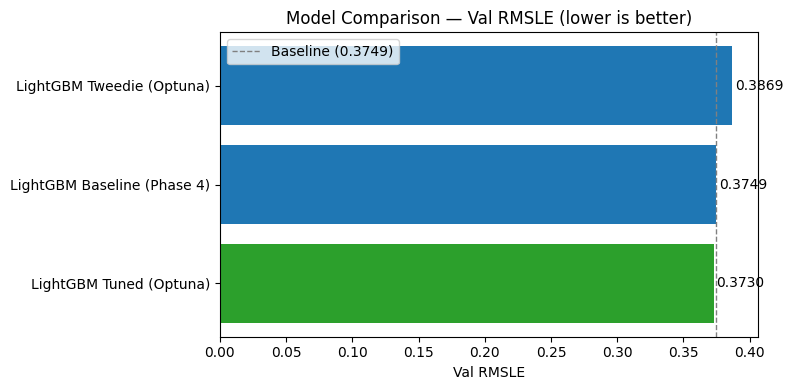

In [12]:
results = pd.DataFrame({
    'Model': [
        'LightGBM Baseline (Phase 4)',
        'LightGBM Tuned (Optuna)',
        'LightGBM Tweedie (Optuna)',
    ],
    'Val RMSLE': [
        0.3749,
        score_lgb_tuned,
        score_tw_tuned,
    ],
})
results['Δ vs Baseline'] = results['Val RMSLE'] - 0.3749
results = results.sort_values('Val RMSLE')
print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
best_rmsle = results.iloc[0]['Val RMSLE']
print(f'\n>>> Best model: {best_model_name} (RMSLE = {best_rmsle:.4f})')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ca02c' if v == results['Val RMSLE'].min() else '#1f77b4' for v in results['Val RMSLE']]
bars = ax.barh(results['Model'], results['Val RMSLE'], color=colors)
ax.axvline(0.3749, color='gray', linestyle='--', linewidth=1, label='Baseline (0.3749)')

for bar, val in zip(bars, results['Val RMSLE']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Val RMSLE')
ax.set_title('Model Comparison — Val RMSLE (lower is better)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'model_comparison.png'), dpi=120)
plt.show()

## 6. Feature Importance — Best Model

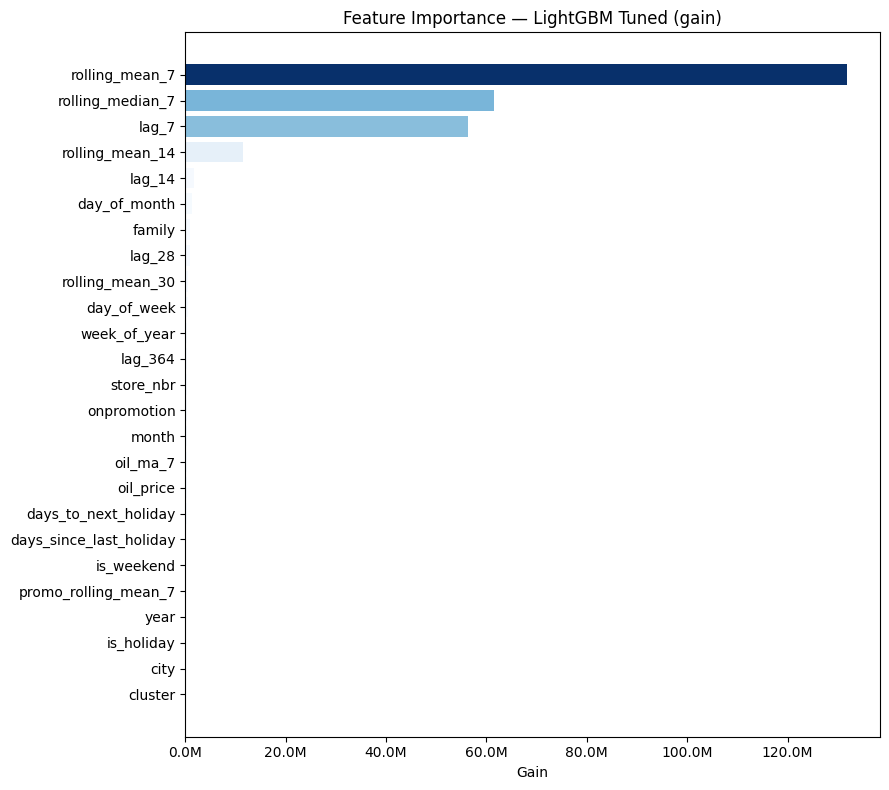

[OK] All features contribute.


In [13]:
# Feature importance от лучшей LightGBM модели (tuned regression)
importance_tuned = pd.Series(
    model_lgb_tuned.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
top = importance_tuned.head(25)
norm = plt.Normalize(top.values.min(), top.values.max())
colors = plt.cm.Blues(norm(top.values[::-1]))
ax.barh(top.index[::-1], top.values[::-1], color=colors)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Gain')
ax.set_title('Feature Importance — LightGBM Tuned (gain)')
plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'feature_importance_tuned.png'), dpi=120)
plt.show()

# Zero-importance check
zero_imp = importance_tuned[importance_tuned == 0]
if len(zero_imp):
    print(f'[!] Zero-importance features: {list(zero_imp.index)}')
else:
    print('[OK] All features contribute.')

## 7. Save Artifacts

In [20]:
# ---- Val predictions от каждой модели (для ensemble в Phase 6) ----
val_preds_all = val[['date', 'store_nbr', 'family', 'sales']].copy()
val_preds_all['lgbm_tuned']  = pred_lgb_tuned
val_preds_all['lgbm_tweedie'] = pred_tw_tuned
val_preds_all.to_csv(os.path.join(artifacts_dir, 'advanced_val_predictions.csv'), index=False)

# ---- Test predictions ----
test_pred_lgb_log = model_lgb_tuned.predict(X_test, num_iteration=model_lgb_tuned.best_iteration)
test_pred_lgb     = np.expm1(test_pred_lgb_log).clip(0)

test_pred_tw = model_tw_tuned.predict(X_test, num_iteration=model_tw_tuned.best_iteration).clip(0)



test_preds_all = test[['date', 'store_nbr', 'family']].copy()
test_preds_all['lgbm_tuned']   = test_pred_lgb
test_preds_all['lgbm_tweedie'] = test_pred_tw
test_preds_all.to_csv(os.path.join(artifacts_dir, 'advanced_test_predictions.csv'), index=False)

# ---- Models ----
joblib.dump(model_lgb_tuned, os.path.join(artifacts_dir, 'lgbm_tuned.pkl'))
joblib.dump(model_tw_tuned,  os.path.join(artifacts_dir, 'lgbm_tweedie.pkl'))


# ---- Optuna studies ----
joblib.dump(study_lgb, os.path.join(artifacts_dir, 'optuna_study_lgbm.pkl'))
joblib.dump(study_tw,  os.path.join(artifacts_dir, 'optuna_study_tweedie.pkl'))


print('=== Saved ===')
print(f'Val predictions:  advanced_val_predictions.csv  ({len(val_preds_all)} rows)')
print(f'Test predictions: advanced_test_predictions.csv ({len(test_preds_all)} rows)')
print(f'Models: lgbm_tuned.pkl, lgbm_tweedie.pkl, xgb_tuned.json')
print(f'Optuna studies: optuna_study_lgbm.pkl, optuna_study_tweedie.pkl, optuna_study_xgb.pkl')

=== Saved ===
Val predictions:  advanced_val_predictions.csv  (26730 rows)
Test predictions: advanced_test_predictions.csv (28512 rows)
Models: lgbm_tuned.pkl, lgbm_tweedie.pkl, xgb_tuned.json
Optuna studies: optuna_study_lgbm.pkl, optuna_study_tweedie.pkl, optuna_study_xgb.pkl


## 8. Summary & Next Steps

### Результаты

| Модель | Val RMSLE | Δ vs Baseline |
|--------|-----------|---------------|
| LightGBM Baseline | 0.3749 | — |
| LightGBM Tuned | *(см. Cell 5)* | *(см. Cell 5)* |
| LightGBM Tweedie | *(см. Cell 5)* | *(см. Cell 5)* |
| XGBoost Tuned | *(см. Cell 5)* | *(см. Cell 5)* |

### Leakage Final Check
- [x] Optuna trials: fit on train, eval on val. Test не использован.
- [x] Tweedie: обучение на raw sales (train only). Val для early stopping.
- [x] XGBoost: те же train/val/test splits, никаких новых фичей.
- [x] Test predictions сохранены, но labels отсутствуют.

### Phase 6: Ensemble
- Weighted average / Stacking трёх моделей (LightGBM Tuned + Tweedie + XGBoost).
- Diversity: MSE vs Tweedie vs XGBoost даёт разные bias/variance профили.
- Генерация `submissions/final_submission.csv`.